# Introduction
First step is to load in the cleaned up dataset for the model

In [15]:
import pandas as pd

df = pd.read_csv("./data/male_players_cleaned.csv")
df.head()

,player_id,overall,age,player_positions,skill_moves,pace,shooting,passing,dribbling,defending,physic,attacking_work_rate,defensive_work_rate
0,158023,93,27,CF,4,93.0,89.0,86.0,96.0,27.0,63.0,2,1
1,20801,92,29,"LW, LM",5,93.0,93.0,81.0,91.0,32.0,79.0,3,1
2,9014,90,30,"RM, LM, RW",4,93.0,86.0,83.0,92.0,32.0,64.0,3,1
3,41236,90,32,ST,4,76.0,91.0,81.0,86.0,34.0,86.0,2,1
4,41,89,30,"CM, LW",4,75.0,72.0,89.0,91.0,59.0,63.0,3,2


# Data split
Now we have to split the data for validation set and training set and test set.

In [16]:
from sklearn.model_selection import train_test_split

# 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, shuffle=True)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, shuffle=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (100529, 13)
Validation shape: (21542, 13)
Test shape: (21543, 13)


# Linear Regression

This is a linear regression of the dataset.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target variable
features = ['age', 'player_positions', 'skill_moves', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_work_rate', 'defensive_work_rate']
target = 'overall'

# Prepare data
X_train = train_df[features]
X_val = val_df[features]
X_test = test_df[features]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

# One-hot encode categorical columns consistently
X_train = pd.get_dummies(X_train, dtype=int)
X_val = pd.get_dummies(X_val, dtype=int)
X_test = pd.get_dummies(X_test, dtype=int)

# Align val/test to training columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate on validation set
y_val_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)
print("Validation MSE:", mse)
print("Validation R^2 Score:", r2)

# Predict and evaluate on test set
y_test_pred = model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("Test MSE:", test_mse)
print("Test R^2 Score:", test_r2)

Validation MSE: 7.143390137444205
Validation R^2 Score: 0.8525021156796196
Test MSE: 7.239135841765625
Test R^2 Score: 0.8506609057818264


# Decision Tree Regression
One of the models we want to test is a decision tree regression model

In [4]:
X_train = train_df.drop(columns=["overall","player_id"])
y_train = train_df["overall"]

X_val = val_df.drop(columns=["overall","player_id"])
y_val = val_df["overall"]

X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

## Hyperparameter search

We want to find the max depth that produces smallest MAE. We therefore do a hyperparameter search using the validation set and plot the result

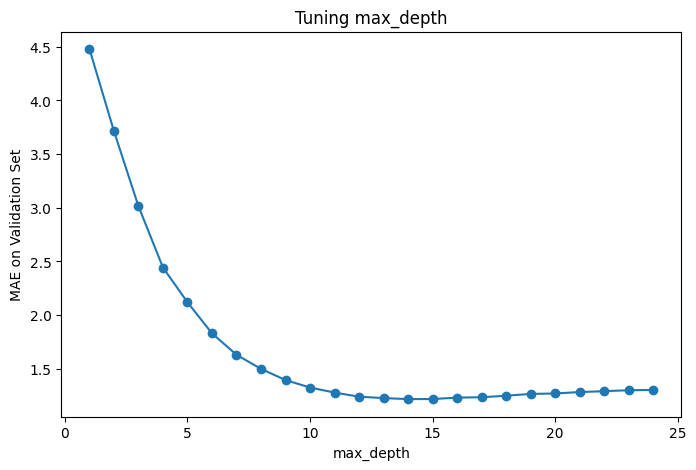

Best max_depth: 14


In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

depths = list(range(1, 25))
mae_scores = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    mae_scores.append(mae)

plt.figure(figsize=(8,5))
plt.plot(depths, mae_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("MAE on Validation Set")
plt.title("Tuning max_depth")
plt.show()

best_depth = depths[mae_scores.index(min(mae_scores))]
print("Best max_depth:", best_depth)

In [12]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
model.fit(X_train, y_train)

X_test = test_df.drop(columns=["overall","player_id"])
y_test = test_df["overall"]

X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", np.sqrt(mse))
print("R²:", r2_score(y_test, y_pred))

MAE: 1.2267155855582514
RMSE: 1.6182329622541574
R²: 0.9459782220987657


In [17]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False)

print(feature_importance)

                               feature  importance
4                              passing    0.358807
6                            defending    0.269386
5                            dribbling    0.208493
3                             shooting    0.084906
7                               physic    0.064098
..                                 ...         ...
700       player_positions_LB, LWB, LW    0.000000
701   player_positions_LB, LWB, LW, CB    0.000000
702       player_positions_LB, LWB, RB    0.000000
703  player_positions_LB, LWB, RB, RWB    0.000000
723        player_positions_LB, RM, CM    0.000000

[1718 rows x 2 columns]
